In [38]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

In [39]:
tabla, jd, X = pc.consulta_horizons(
    id = 'Apophis',
    epochs = '2026-04-20',
    location = '@SSB'
)
X

array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09, -2.72244445e+04,
       -4.00763765e+03, -4.30333986e+02])

Para la determinación de los elementos orbitales necesito estos vectores:
$\vec r, \vec v, \vec h, \vec e, \vec n$

In [40]:
rvec = X[:3]
r = np.linalg.norm(rvec)

vvec = X[3:]
v = np.linalg.norm(vvec)

rvec, vvec

(array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09]),
 array([-27224.44453608,  -4007.63764628,   -430.33398559]))

In [41]:
hvec = np.cross(rvec, vvec)
h = np.linalg.norm(hvec)

mu = pc.constantes.mu_sun #Aproximado

evec = np.cross(vvec, hvec)/mu - rvec/r
e = np.linalg.norm(evec)

nvec = np.cross([0,0,1], hvec)
n = np.linalg.norm(nvec)

Vamos a determinar los elementos orbitales $(p, e, I, \Omega, \omega, f)$

In [42]:
p = h**2/mu
e = e
I = np.arccos(hvec[2]/h)
I * 180/np.pi

np.float64(3.3475799477925516)

La órbita osculatriz de Apophis hoy a la medianoche es de 3°

In [43]:
omegap = np.arccos(nvec@evec/(n*e))
omegap * 180/np.pi

np.float64(126.30633780951214)

In [44]:
Omegap = np.arccos(nvec@[1,0,0]/n) 
Omega = Omegap if nvec[1] > 0 else 2 * np.pi - Omegap
Omega * 180/np.pi

np.float64(203.8811521637987)

In [45]:
fp = np.arccos(rvec@evec/(r*e))
f = fp if rvec@vvec/r > 0 else 2 * np.pi - fp
f * 180/np.pi

np.float64(137.0639111789069)

In [46]:
def elementos_orbitales_desde_estado(rvec, vvec, mu, tol=1e-12):
    rvec = np.asarray(rvec, dtype=float)
    vvec = np.asarray(vvec, dtype=float)

    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)

    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    kvec = np.array([0.0, 0.0, 1.0])
    nvec = np.cross(kvec, hvec)
    n = np.linalg.norm(nvec)

    evec = np.cross(vvec, hvec) / mu - rvec / r
    e = np.linalg.norm(evec)

    p = h**2 / mu
    I = np.arccos(hvec[2] / h)

    # Longitud del nodo ascendente
    if n > tol:
        Omegap = np.arccos(np.dot(nvec, [1, 0, 0]) / n)
        Omega = Omegap if nvec[1] > 0 else 2 * np.pi - Omegap
    else:
        Omega = 0.0

    # Argumento del periastro
    if e > tol and n > tol:
        omegap = np.arccos(np.dot(nvec, evec) / (n * e))
        omega = omegap if evec[2] > 0 else 2 * np.pi - omegap
    else:
        omega = 0.0

    # Anomalía verdadera
    if e > tol:
        fp = np.arccos(np.dot(rvec, evec) / (r * e))
        f = fp if np.dot(rvec, vvec) > 0 else 2 * np.pi - fp
    else:
        f = 0.0

    return p, e, I, Omega, omega, f


# Ejemplo con tus variables actuales:
p, e, I, Omega, omega, f = elementos_orbitales_desde_estado(rvec, vvec, mu)
print(f"p: {p}, e: {e}, I: {I*180/np.pi}, Omega: {Omega*180/np.pi}, omega: {omega*180/np.pi}, f: {f*180/np.pi}")

p: 131509557547.50772, e: 0.19681731768435504, I: 3.3475799477925516, Omega: 203.8811521637987, omega: 126.30633780951214, f: 137.0639111789069


La órbita del sol

In [47]:
tabla, jds, Xs = pc.consulta_horizons(
    id = 'Sun',
    location = '@SSB',
    epochs = dict(start = '2026-04-20', stop = '2038-04-20', step = '180d')
)

Xs = np.array(Xs)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7704\276504068.py:37: RuntimeWarning: invalid value encountered in arccos
  fp = np.arccos(np.dot(rvec, evec) / (r * e))


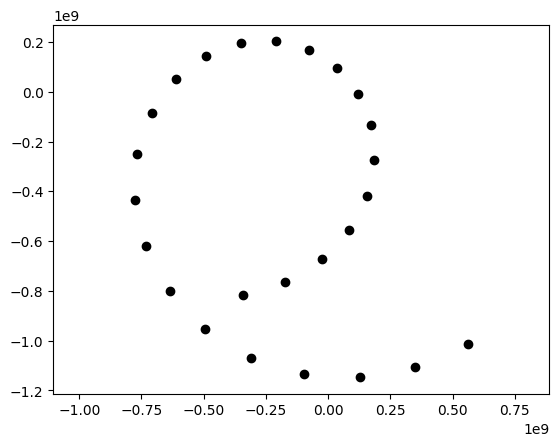

In [51]:
mu = pc.constantes.mu_sun + pc.constantes.mu_jupiter + pc.constantes.mu_saturn

for i, jd in enumerate(jds):
    rvec = Xs[i, :3]
    vvec = Xs[i, 3:]

    p, e, I, Omega, omega, f = elementos_orbitales_desde_estado(rvec, vvec, mu)
    
    plt.plot(rvec[0], rvec[1], 'ko')
    
plt.axis('equal')
plt.show()